In [ ]:
!pip install tensorflow opencv-python scikit-learn lime seaborn matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 27.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a0d945fc2206303d3528bc11d66c7c23039598faeba20dcffddec62720bcea28
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


In [ ]:
BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"

TRAIN_DIR = os.path.join(BASE_PATH, "train_set")
VAL_DIR   = os.path.join(BASE_PATH, "validation_set")
TEST_DIR  = os.path.join(BASE_PATH, "test_set")

IMG_SIZE = (224, 224)
CLASSES = ["nodule", "non nodule"]
NUM_CLASSES = 2


In [ ]:
def white_balance(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    return cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2BGR)

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16,16))
    cl = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((cl,a,b)), cv2.COLOR_LAB2BGR)

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, IMG_SIZE)
    img = white_balance(img)
    img = apply_clahe(img)
    return img / 255.0


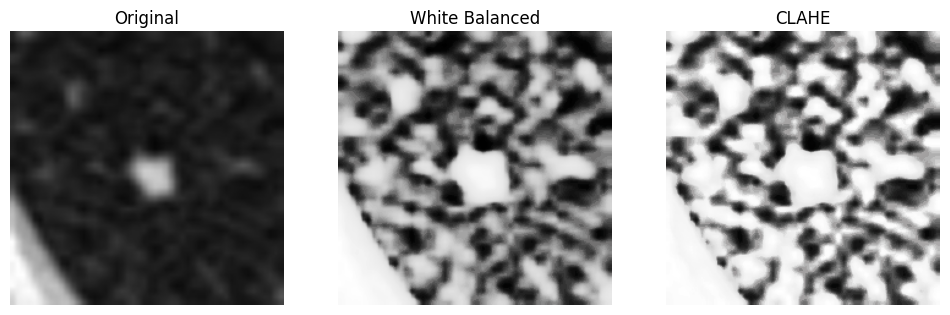

In [ ]:
sample = os.listdir(os.path.join(TRAIN_DIR, "nodule"))[0]
path = os.path.join(TRAIN_DIR, "nodule", sample)

orig = cv2.imread(path)
orig = cv2.resize(orig, IMG_SIZE)
wb = white_balance(orig)
clahe = apply_clahe(wb)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(orig[:,:,::-1]); plt.axis("off")
plt.subplot(1,3,2); plt.title("White Balanced"); plt.imshow(wb[:,:,::-1]); plt.axis("off")
plt.subplot(1,3,3); plt.title("CLAHE"); plt.imshow(clahe[:,:,::-1]); plt.axis("off")
plt.show()


In [ ]:
def data_generator(directory, batch_size=16):
    while True:
        X, y = [], []
        for idx, cls in enumerate(CLASSES):
            cls_path = os.path.join(directory, cls)
            for img_name in os.listdir(cls_path):
                img_path = os.path.join(cls_path, img_name)
                try:
                    img = preprocess_image(img_path)
                    X.append(img)
                    y.append(idx)

                    if len(X) == batch_size:
                        yield np.array(X), tf.keras.utils.to_categorical(y, NUM_CLASSES)
                        X, y = [], []

                except:
                    continue


In [ ]:
def LGAM(x, enable=True):
    if not enable:
        return x

    c = x.shape[-1]

    # -------- Spatial Attention Block (SAB) --------
    avg_pool = layers.Lambda(
        lambda t: tf.reduce_mean(t, axis=-1, keepdims=True)
    )(x)

    max_pool = layers.Lambda(
        lambda t: tf.reduce_max(t, axis=-1, keepdims=True)
    )(x)

    spatial = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(spatial)

    sab_out = layers.Multiply()([x, spatial])

    # -------- Channel Attention Block (CAB) --------
    gmp = layers.GlobalMaxPooling2D()(sab_out)
    gap = layers.GlobalAveragePooling2D()(sab_out)

    shared_fc1 = layers.Dense(c // 8, activation="relu")
    shared_fc2 = layers.Dense(c, activation="sigmoid")

    ca1 = shared_fc2(shared_fc1(gmp))
    ca2 = shared_fc2(shared_fc1(gap))

    ca = layers.Add()([ca1, ca2])
    ca = layers.Reshape((1, 1, c))(ca)

    return layers.Multiply()([sab_out, ca])


In [ ]:
def LungAttNet(lr=0.001, optimizer="Nadam", attention=True):
    inp = layers.Input(shape=(224,224,3))

    x = layers.Conv2D(32,3,activation='relu')(inp)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64,3,activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128,3,activation='relu')(x)
    x = layers.AveragePooling2D(2)(x)

    x = layers.Conv2D(256,3,activation='relu')(x)
    x = LGAM(x, attention)

    x = layers.Conv2D(256,3,activation='relu')(x)
    x = layers.Flatten()(x)

    x = layers.Dense(128,activation='relu')(x)
    x = layers.Dense(256,activation='relu')(x)
    out = layers.Dense(NUM_CLASSES,activation='softmax')(x)

    model = models.Model(inp,out)

    opt = optimizers.Nadam(lr) if optimizer=="Nadam" else optimizers.Adam(lr)
    model.compile(opt, "categorical_crossentropy", metrics=["accuracy"])
    return model


In [ ]:
def get_image_paths(directory):
    paths, labels = [], []
    for idx, cls in enumerate(CLASSES):
        cls_path = os.path.join(directory, cls)
        for img in os.listdir(cls_path):
            paths.append(os.path.join(cls_path, img))
            labels.append(idx)
    return np.array(paths), np.array(labels)

paths, labels = get_image_paths(TRAIN_DIR)


In [ ]:
def indexed_generator(paths, labels, indices, batch_size=16):
    while True:
        np.random.shuffle(indices)
        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i:i+batch_size]
            X, y = [], []
            for j in batch_idx:
                X.append(preprocess_image(paths[j]))
                y.append(labels[j])
            yield np.array(X), tf.keras.utils.to_categorical(y, NUM_CLASSES)



Training Fold 1
Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 66s 193ms/step - accuracy: 0.8171 - loss: 0.4929 - val_accuracy: 0.8135 - val_loss: 0.4799
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 50s 180ms/step - accuracy: 0.8476 - loss: 0.4333 - val_accuracy: 0.8311 - val_loss: 0.4388
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 48s 185ms/step - accuracy: 0.8398 - loss: 0.3907 - val_accuracy: 0.8359 - val_loss: 0.3951
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 47s 180ms/step - accuracy: 0.8561 - loss: 0.3565 - val_accuracy: 0.8366 - val_loss: 0.3859
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 49s 188ms/step - accuracy: 0.8569 - loss: 0.3438 - val_accuracy: 0.8506 - val_loss: 0.3695
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 46s 179ms/step - accuracy: 0.8601 - loss: 0.3281 - val_accuracy: 0.8552 - val_loss: 0.3712
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 45s 175ms/step - accuracy: 0.8842 - loss: 0.2897 - val_accuracy: 0.8581 - val_loss: 0.3586
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - accuracy:

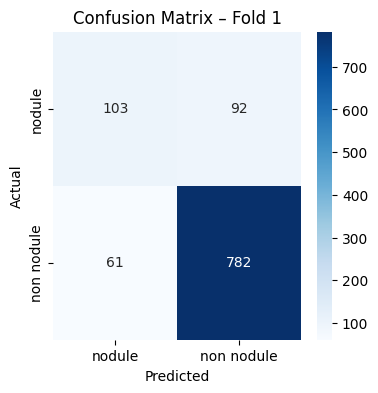


Training Fold 2
Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 55s 183ms/step - accuracy: 0.8263 - loss: 0.5331 - val_accuracy: 0.8369 - val_loss: 0.4242
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 51s 183ms/step - accuracy: 0.8382 - loss: 0.4129 - val_accuracy: 0.8418 - val_loss: 0.4149
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 47s 180ms/step - accuracy: 0.8478 - loss: 0.3916 - val_accuracy: 0.8369 - val_loss: 0.3980
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 48s 185ms/step - accuracy: 0.8515 - loss: 0.3679 - val_accuracy: 0.8444 - val_loss: 0.3543
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 47s 182ms/step - accuracy: 0.8615 - loss: 0.3381 - val_accuracy: 0.8545 - val_loss: 0.3738
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 46s 176ms/step - accuracy: 0.8824 - loss: 0.2933 - val_accuracy: 0.8708 - val_loss: 0.2849
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 44s 171ms/step - accuracy: 0.9204 - loss: 0.2177 - val_accuracy: 0.8650 - val_loss: 0.3480
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - accuracy:

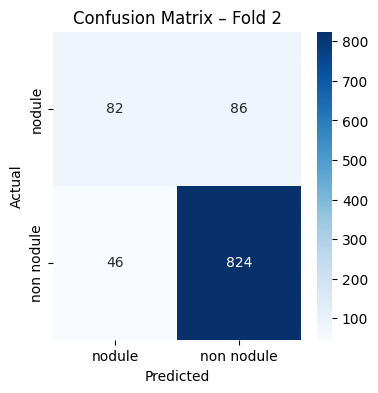


Training Fold 3
Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 55s 183ms/step - accuracy: 0.8105 - loss: 0.4917 - val_accuracy: 0.8564 - val_loss: 0.4225
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 51s 178ms/step - accuracy: 0.8355 - loss: 0.4492 - val_accuracy: 0.8584 - val_loss: 0.3859
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 46s 179ms/step - accuracy: 0.8407 - loss: 0.3958 - val_accuracy: 0.8574 - val_loss: 0.3818
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 48s 185ms/step - accuracy: 0.8328 - loss: 0.4002 - val_accuracy: 0.8746 - val_loss: 0.3308
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 48s 184ms/step - accuracy: 0.8547 - loss: 0.3665 - val_accuracy: 0.8779 - val_loss: 0.3414
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 45s 176ms/step - accuracy: 0.8531 - loss: 0.3650 - val_accuracy: 0.8541 - val_loss: 0.3771
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 45s 172ms/step - accuracy: 0.8399 - loss: 0.3901 - val_accuracy: 0.8580 - val_loss: 0.3944
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 44s 171ms/step - accuracy:

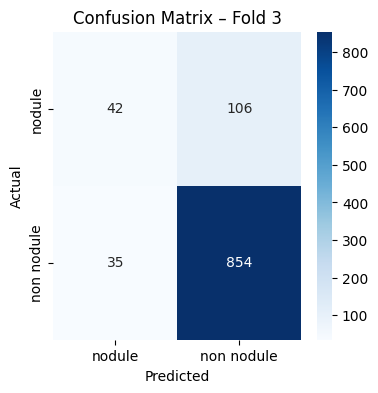


Training Fold 4
Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 55s 186ms/step - accuracy: 0.8281 - loss: 0.4844 - val_accuracy: 0.8213 - val_loss: 0.4650
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 49s 178ms/step - accuracy: 0.8440 - loss: 0.4342 - val_accuracy: 0.8193 - val_loss: 0.4734
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 82s 319ms/step - accuracy: 0.8365 - loss: 0.4491 - val_accuracy: 0.8281 - val_loss: 0.4708
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 47s 183ms/step - accuracy: 0.8374 - loss: 0.4488 - val_accuracy: 0.8188 - val_loss: 0.5035
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 48s 186ms/step - accuracy: 0.8357 - loss: 0.4528 - val_accuracy: 0.8203 - val_loss: 0.4742
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 47s 180ms/step - accuracy: 0.8287 - loss: 0.4614 - val_accuracy: 0.8266 - val_loss: 0.4632
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 77s 299ms/step - accuracy: 0.8366 - loss: 0.4479 - val_accuracy: 0.8198 - val_loss: 0.4790
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 46s 178ms/step - accuracy:

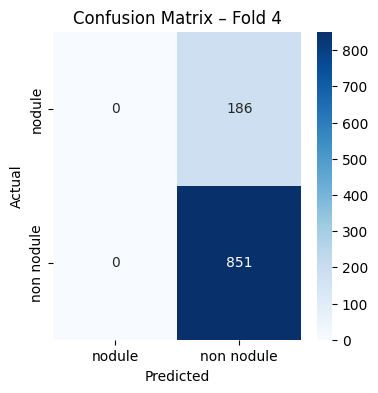


Training Fold 5
Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 54s 184ms/step - accuracy: 0.8080 - loss: 0.5071 - val_accuracy: 0.8564 - val_loss: 0.4287
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 49s 177ms/step - accuracy: 0.8248 - loss: 0.4709 - val_accuracy: 0.8613 - val_loss: 0.3718
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 46s 179ms/step - accuracy: 0.8369 - loss: 0.4109 - val_accuracy: 0.8662 - val_loss: 0.3916
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 46s 180ms/step - accuracy: 0.8345 - loss: 0.4116 - val_accuracy: 0.8746 - val_loss: 0.3411
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 47s 183ms/step - accuracy: 0.8419 - loss: 0.3889 - val_accuracy: 0.8701 - val_loss: 0.3328
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - accuracy: 0.8434 - loss: 0.3712 - val_accuracy: 0.8629 - val_loss: 0.3265
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 45s 174ms/step - accuracy: 0.8619 - loss: 0.3392 - val_accuracy: 0.8668 - val_loss: 0.3136
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 46s 178ms/step - accuracy:

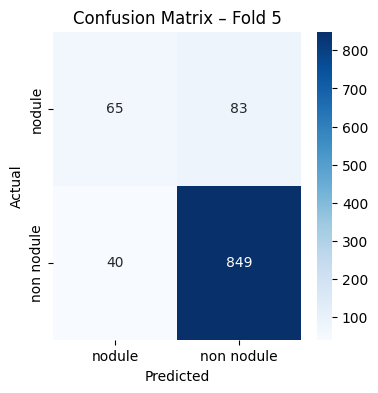

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_cms = []   # for average confusion matrix later

for fold, (tr_idx, va_idx) in enumerate(kf.split(paths), 1):
    print(f"\nTraining Fold {fold}")

    train_gen = indexed_generator(paths, labels, tr_idx)
    val_gen   = indexed_generator(paths, labels, va_idx)

    model = LungAttNet()

    model.fit(
        train_gen,
        steps_per_epoch=len(tr_idx)//16,
        validation_data=val_gen,
        validation_steps=len(va_idx)//16,
        epochs=10,
        verbose=1
    )

    # -------------------------------
    # Confusion Matrix for this fold
    # -------------------------------
    y_true, y_pred = [], []

    for i in va_idx:
        img = preprocess_image(paths[i])
        pred = np.argmax(model.predict(img[np.newaxis, ...], verbose=0))
        y_pred.append(pred)
        y_true.append(labels[i])

    cm = confusion_matrix(y_true, y_pred)
    all_cms.append(cm)

    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASSES,
        yticklabels=CLASSES
    )
    plt.title(f"Confusion Matrix – Fold {fold}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    plt.close()


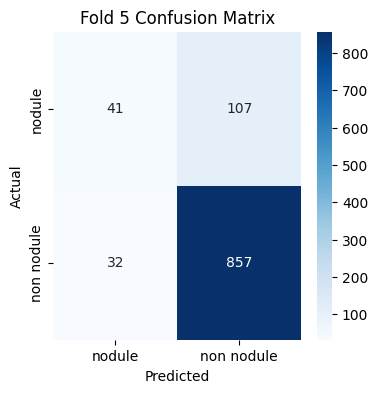

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.title(f"Fold {fold} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.close()   # IMPORTANT


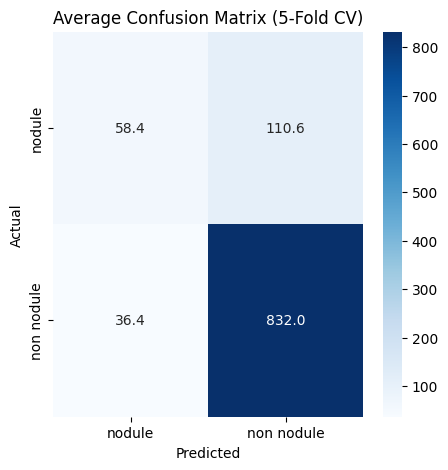

In [ ]:
avg_cm = np.mean(all_cms, axis=0)

plt.figure(figsize=(5,5))
sns.heatmap(
    avg_cm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.title("Average Confusion Matrix (5-Fold CV)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, recall_score

acc = accuracy_score(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)

print(f"Fold {fold} Accuracy     : {acc*100:.2f}%")
print(f"Fold {fold} Sensitivity  : {sens*100:.2f}%")


Fold 5 Accuracy     : 88.14%
Fold 5 Sensitivity  : 95.50%


In [ ]:
!pip uninstall -y flwr
!pip install -U 'flwr[simulation]'

Found existing installation: flwr 1.25.0
Uninstalling flwr-1.25.0:
  Successfully uninstalled flwr-1.25.0
  Using cached flwr-1.25.0-py3-none-any.whl.metadata (14 kB)
Using cached flwr-1.25.0-py3-none-any.whl (727 kB)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ---- Example placeholder data ----
# Replace this with your real lung images & labels
all_images = torch.randn(600, 1, 224, 224)
all_labels = torch.randint(0, 2, (600,))

NUM_CLIENTS = 6
BATCH_SIZE = 16

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10)
])

test_tf = None


class LungDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]
        if self.transform:
            x = self.transform(x)
        return x, y


client_train_loaders = []
client_test_loaders = []

client_size = len(all_images) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * client_size
    end = start + client_size

    imgs = all_images[start:end]
    labs = all_labels[start:end]

    split = int(0.8 * len(imgs))

    train_ds = LungDataset(imgs[:split], labs[:split], train_tf)
    test_ds = LungDataset(imgs[split:], labs[split:], test_tf)

    client_train_loaders.append(
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    )
    client_test_loaders.append(
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    )

print("Client loaders created:", len(client_train_loaders))


Client loaders created: 6


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision # Added this import statement

class LGAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.att = nn.Sequential(
            nn.Conv2d(channels, channels // 8, 1),
            nn.ReLU(),
            nn.Conv2d(channels // 8, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.att(x)

class LungATTNet(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.densenet121(weights="IMAGENET1K_V1")
        self.backbone = backbone.features
        self.lgam = LGAM(1024)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1024, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.lgam(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

class ATTNetLGAM(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = torchvision.models.resnet18(weights="DEFAULT")
        self.backbone.fc = nn.Identity()

        self.lgam = LGAM(channels=512) # Changed 'in_channels' to 'channels'

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2) # Changed output to 2 logits for 2 classes
        )

    def forward(self, x):
        feats = self.backbone(x)
        feats = self.lgam(feats)
        return self.classifier(feats) # Removed .squeeze(1) to return (batch_size, 2) logits


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = -self.alpha * (1 - pt) ** self.gamma * torch.log(pt + 1e-8)
        return loss.mean()


In [ ]:
import torch.nn.functional as F

def train_client_fl(model, loader, device, epochs=5):
    model.train()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    criterion = FocalLoss(alpha=0.75, gamma=2.0)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)

            # Convert scalar labels to one-hot encoding for FocalLoss
            num_classes = 2 # Assuming 2 classes as defined in ATTNetLGAM
            y_one_hot = F.one_hot(y, num_classes=num_classes).float()

            loss = criterion(logits, y_one_hot)
            loss.backward()
            optimizer.step()

        scheduler.step()

In [ ]:
from copy import deepcopy

def fedavg(models):
    avg = deepcopy(models[0].state_dict())
    for k in avg.keys():
        for i in range(1, len(models)):
            avg[k] += models[i].state_dict()[k]
        avg[k] /= len(models)
    return avg

In [ ]:
def personalize(model):
    for p in model.backbone.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True
    for p in model.lgam.parameters():
        p.requires_grad = True


In [ ]:
def local_calibration(model, loader, device):
    model.train()
    personalize(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.5]).to(device))

    for _ in range(8):  # 5–10 epochs
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()


In [ ]:
for r in range(10):
    print(f"\n========== Federated Round {r+1} ==========")

    for i in range(6):
        train_client_fl(clients[i], client_train_loaders[i], device, epochs=8)
        print(f"Client {i+1} trained")

    avg_weights = fedavg(clients)

    for i in range(6):
        clients[i].load_state_dict(avg_weights)

    print("Global model updated")


========== Federated Round 1 ==========
Client 1 trained
Client 2 trained
Client 3 trained
Client 4 trained
Client 5 trained
Client 6 trained
Global model updated

========== Federated Round 2 ==========
Client 1 trained
Client 2 trained
Client 3 trained
Client 4 trained
Client 5 trained
Client 6 trained
Global model updated

========== Federated Round 3 ==========
Client 1 trained
Client 2 trained
Client 3 trained
Client 4 trained
Client 5 trained
Client 6 trained
Global model updated

========== Federated Round 4 ==========
Client 1 trained
Client 2 trained
Client 3 trained
Client 4 trained
Client 5 trained
Client 6 trained
Global model updated

========== Federated Round 5 ==========
Client 1 trained
Client 2 trained
Client 3 trained
Client 4 trained
Client 5 trained
Client 6 trained
Global model updated

========== Federated Round 6 ==========
Client 1 trained
Client 2 trained
Client 3 trained
Client 4 trained
Client 5 trained
Client 6 trained
Global model updated

========== Fede

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clients = [ATTNetLGAM().to(device) for _ in range(NUM_CLIENTS)]

ROUNDS = 10
LOCAL_EPOCHS = 8 # Match epochs in train_client_fl

In [ ]:
import torch.nn as nn # Import nn module
import torch # Ensure torch is imported for tensor operations

print("\n========== Local Personalization Phase ==========")

# Define the weighted CrossEntropyLoss criterion for personalization
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.5]).to(device)) # Example weights

for i in range(6):

    optimizer = torch.optim.AdamW(
        clients[i].parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=10
    )

    clients[i].train()

    for epoch in range(10):   # 10 local personalization epochs
        total_loss = 0.0

        for x, y in client_train_loaders[i]:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = clients[i](x)
            loss = criterion(logits, y) # Use the defined criterion with scalar labels
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

    print(f"Client {i+1} personalized")



========== Local Personalization Phase ==========
Client 1 personalized
Client 2 personalized
Client 3 personalized
Client 4 personalized
Client 5 personalized
Client 6 personalized


In [ ]:
print("\n========== Final Evaluation ==========")

accs, sens = [], []

for i in range(6):
    acc, sen = evaluate(
        clients[i],
        client_test_loaders[i],
        device,
        threshold=0.35
    )

    accs.append(acc)
    sens.append(sen)

    print(
        f"Client {i+1}: "
        f"Accuracy = {acc*100:.2f}%, "
        f"Sensitivity = {sen*100:.2f}%"
    )

print("\nGlobal (mean across clients):")
print(f"Accuracy    : {sum(accs)/len(accs)*100:.2f}%")
print(f"Sensitivity : {sum(sens)/len(sens)*100:.2f}%")



========== Final Evaluation ==========
Client 1: Accuracy = 50.00%, Sensitivity = 100.00%
Client 2: Accuracy = 50.00%, Sensitivity = 100.00%
Client 3: Accuracy = 55.00%, Sensitivity = 100.00%
Client 4: Accuracy = 50.00%, Sensitivity = 100.00%
Client 5: Accuracy = 30.00%, Sensitivity = 100.00%
Client 6: Accuracy = 55.00%, Sensitivity = 100.00%

Global (mean across clients):
Accuracy    : 48.33%
Sensitivity : 100.00%


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# Example: Replace this with your actual Lung CT/X-ray images and labels
# Suppose images are 28x28 grayscale, and labels are 0 or 1
all_images = torch.randn(600, 1, 28, 28)  # 600 sample images
all_labels = torch.randint(0, 2, (600,))  # 600 labels (2 classes)

num_clients = 6
client_train_loaders = []
client_test_loaders = []

# Data transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

test_transform = transforms.ToTensor()

# Custom Dataset
class LungDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

# Split dataset per client
client_data_size = len(all_images) // num_clients

for i in range(num_clients):
    start = i * client_data_size
    end = start + client_data_size
    images = all_images[start:end]
    labels = all_labels[start:end]

    # Split into 80% train, 20% test
    split_idx = int(0.8 * len(images))
    train_dataset = LungDataset(images[:split_idx], labels[:split_idx], transform=train_transform)
    test_dataset = LungDataset(images[split_idx:], labels[split_idx:], transform=test_transform)

    client_train_loaders.append(DataLoader(train_dataset, batch_size=16, shuffle=True))
    client_test_loaders.append(DataLoader(test_dataset, batch_size=16, shuffle=False))


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"
TRAIN_DIR = os.path.join(BASE_PATH, "train_set")

# Corrected classes list to match the dataset structure
classes = ["nodule", "non nodule"]
class_counts = []

for cls in classes:
    path = os.path.join(TRAIN_DIR, cls)
    count = len(os.listdir(path))
    class_counts.append(count)

print("Class distribution:", dict(zip(classes, class_counts)))

Class distribution: {'nodule': 845, 'non nodule': 4342}


In [ ]:
import torch

# Number of samples per class
class_counts = [4342, 845]  # order: [non_nodule, nodule]

total_samples = sum(class_counts)
num_classes = len(class_counts)

class_weights = [total_samples / (num_classes * c) for c in class_counts]
print("Class weights:", class_weights)

# Convert to tensor for PyTorch
device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)


Class weights: [0.5973053892215568, 3.0692307692307694]


In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(weight=class_weights)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# =================== Setup ===================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"

# Define paths and constants (explicitly redefining for consistency)
BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"
TRAIN_DIR = os.path.join(BASE_PATH, "train_set")
VAL_DIR   = os.path.join(BASE_PATH, "validation_set")
TEST_DIR  = os.path.join(BASE_PATH, "test_set")

IMG_SIZE = (224, 224)
CLASSES = ["nodule", "non nodule"]
NUM_CLASSES = 2

# =================== Dataset ===================
class LungDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform
        self.classes = ['nodule', 'non nodule'] # Corrected class order to match dataset structure

        for idx, cls in enumerate(self.classes):
            cls_folder = os.path.join(root_dir, cls)
            # Ensure the directory exists before listing its contents
            if not os.path.exists(cls_folder):
                raise FileNotFoundError(f"Directory not found: {cls_folder}")
            for file in os.listdir(cls_folder):
                self.images.append(os.path.join(cls_folder, file))
                self.labels.append(idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# =================== Transforms ===================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =================== Lung-AttNet Architecture ===================
class LungAttNet(nn.Module):
    def __init__(self):
        super(LungAttNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(256*14*14, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

# =================== Class Weights ===================
# Example from your dataset
class_counts = [4342, 845]  # [non_nodule, nodule]
total_samples = sum(class_counts)
num_classes = len(class_counts)
class_weights = [total_samples / (num_classes * c) for c in class_counts]
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# =================== Federated Setup ===================
def train_one_client(model, dataloader, optimizer, criterion, epochs=3):
    model.train()
    for epoch in range(epochs):
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    return model.state_dict()

def evaluate(model, dataloader, threshold=0.6):
    model.eval()
    correct = 0
    total = 0
    TP = 0
    FN = 0
    FP = 0
    TN = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = (probs[:,1] > threshold).long()

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            TP += ((preds==1) & (labels==1)).sum().item()
            TN += ((preds==0) & (labels==0)).sum().item()
            FP += ((preds==1) & (labels==0)).sum().item()
            FN += ((preds==0) & (labels==1)).sum().item()

    accuracy = correct / total * 100
    sensitivity = TP / (TP + FN) * 100 if (TP+FN) > 0 else 0
    specificity = TN / (TN + FP) * 100 if (TN+FP) > 0 else 0
    precision = TP / (TP + FP) * 100 if (TP+FP) > 0 else 0
    return accuracy, sensitivity, specificity, precision

def federated_average(weights_list, weights_count):
    avg_weights = copy.deepcopy(weights_list[0])
    for key in avg_weights.keys():
        avg_weights[key] = sum([weights_list[i][key]*weights_count[i] for i in range(len(weights_list))]) / sum(weights_count)
    return avg_weights

# =================== Main Training ===================
from sklearn.model_selection import KFold

# Use the correct TRAIN_DIR instead of a hardcoded '/content/train'
dataset = LungDataset(TRAIN_DIR, transform=transform)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

global_model = LungAttNet().to(device)

for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(dataset))), 1):
    print(f"\n==== Fold {fold} ====")

    train_subset = torch.utils.data.Subset(dataset, train_idx)
    val_subset   = torch.utils.data.Subset(dataset, val_idx)

    # Split train_subset among 5 clients
    # Ensure sum of lengths matches len(train_subset) to avoid ValueError
    split_sizes = [len(train_subset) // 5] * 4
    split_sizes.append(len(train_subset) - sum(split_sizes))
    client_datasets = torch.utils.data.random_split(train_subset, split_sizes)

    client_weights = []
    client_samples = []

    for client_id, c_data in enumerate(client_datasets):
        dataloader = DataLoader(c_data, batch_size=32, shuffle=True)
        client_model = copy.deepcopy(global_model)
        optimizer = torch.optim.Adam(client_model.parameters(), lr=1e-4)
        client_state = train_one_client(client_model, dataloader, optimizer, criterion, epochs=3)
        client_weights.append(client_state)
        client_samples.append(len(c_data))

    # Federated averaging
    global_weights = federated_average(client_weights, client_samples)
    global_model.load_state_dict(global_weights)

    # Evaluate
    val_loader = DataLoader(val_subset, batch_size=32)
    acc, sens, spec, prec = evaluate(global_model, val_loader, threshold=0.6)
    print(f"Accuracy: {acc:.2f}%, Sensitivity: {sens:.2f}%, Specificity: {spec:.2f}%, Precision: {prec:.2f}%")


==== Fold 1 ====
Accuracy: 81.21%, Sensitivity: 100.00%, Specificity: 0.00%, Precision: 81.21%

==== Fold 2 ====
Accuracy: 83.82%, Sensitivity: 100.00%, Specificity: 0.00%, Precision: 83.82%

==== Fold 3 ====
Accuracy: 85.92%, Sensitivity: 100.00%, Specificity: 1.35%, Precision: 85.89%

==== Fold 4 ====
Accuracy: 82.26%, Sensitivity: 100.00%, Specificity: 1.08%, Precision: 82.22%

==== Fold 5 ====
Accuracy: 86.21%, Sensitivity: 99.66%, Specificity: 5.41%, Precision: 86.35%
